# Amazon Sales Dataset — Exploratory Data Analysis
### What Do Amazon's Sales Patterns Reveal About Customer Behavior, Revenue Drivers, and Operational Risks?

---

**Author:** Noor ul Huda  
**Role:** Data Analyst  
**LinkedIn:** [linkedin.com/in/noor-ul-huda](https://www.linkedin.com/in/noor-ul-huda-92b040358)  
**GitHub:** [github.com/noorhuda523](https://github.com/noorhuda523)  

---

## About This Notebook

This notebook performs a comprehensive exploratory data analysis on the Amazon Sales Dataset — a transactional record covering orders, products, customers, and financials across multiple countries and categories.

The analysis is structured to answer five core business questions:

- Which product categories generate the most revenue — and which underperform?
- How do discounts actually affect sales volume and total revenue?
- Which countries and regions drive the most order activity?
- What does the order status distribution reveal about fulfilment quality and cancellation risk?
- Which payment methods dominate — and does payment method correlate with cancellations?

---

## Table of Contents

1. Environment Setup  
2. Data Loading and Overview  
3. Data Cleaning and Quality Check  
4. Revenue and Sales Distribution  
5. Category and Product Analysis  
6. Geographic Analysis  
7. Order Status and Fulfilment  
8. Payment Method Analysis  
9. Discount and Pricing Relationships  
10. Correlation Analysis  
11. Hypothesis Testing  
12. Anomalies and Outliers  
13. Key Insights and Conclusions  

---

In [3]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/rohiteng/amazon-sales-dataset/Amazon.csv


## Section 1: Environment Setup

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Color Palette ──────────────────────────────────────────────────────────
BLUE    = '#2C7BB6'
RED     = '#D73027'
GREEN   = '#1A9641'
ORANGE  = '#FDAE61'
PURPLE  = '#762A83'
CORAL   = '#F46D43'
PALETTE = [BLUE, RED, GREEN, ORANGE, PURPLE, CORAL, '#74ADD1', '#A6D96A', '#ABD9E9', '#FEE08B']

# ── Plot Configuration ─────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi'        : 120,
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
    'axes.titlesize'    : 13,
    'axes.titleweight'  : 'bold',
    'axes.labelsize'    : 11,
    'font.family'       : 'serif'
})
sns.set_style('whitegrid')

print('Environment configured successfully.')

Environment configured successfully.


## Section 2: Data Loading and Overview

The Amazon Sales Dataset contains transactional records including order details, product categories, 
customer locations, payment methods, pricing, discounts, taxes, and shipping costs. 
We begin by loading the data and understanding its structure before any analysis.

In [6]:
df = pd.read_csv('/kaggle/input/datasets/rohiteng/amazon-sales-dataset/Amazon.csv')

print('Dataset loaded successfully.')
print(f'  Rows    : {df.shape[0]}')
print(f'  Columns : {df.shape[1]}')
print()
df.head(10)

Dataset loaded successfully.
  Rows    : 100000
  Columns : 20



,OrderID,OrderDate,CustomerID,CustomerName,ProductID,ProductName,Category,Brand,Quantity,UnitPrice,Discount,Tax,ShippingCost,TotalAmount,PaymentMethod,OrderStatus,City,State,Country,SellerID
0,ORD0000001,2023-01-31,CUST001504,Vihaan Sharma,P00014,Drone Mini,Books,BrightLux,3,106.59,0.00,0.00,0.09,319.86,Debit Card,Delivered,Washington,DC,India,SELL01967
1,ORD0000002,2023-12-30,CUST000178,Pooja Kumar,P00040,Microphone,Home & Kitchen,UrbanStyle,1,251.37,0.05,19.10,1.74,259.64,Amazon Pay,Delivered,Fort Worth,TX,United States,SELL01298
2,ORD0000003,2022-05-10,CUST047516,Sneha Singh,P00044,Power Bank 20000mAh,Clothing,UrbanStyle,3,35.03,0.10,7.57,5.91,108.06,Debit Card,Delivered,Austin,TX,United States,SELL00908
3,ORD0000004,2023-07-18,CUST030059,Vihaan Reddy,P00041,Webcam Full HD,Home & Kitchen,Zenith,5,33.58,0.15,11.42,5.53,159.66,Cash on Delivery,Delivered,Charlotte,NC,India,SELL01164
4,ORD0000005,2023-02-04,CUST048677,Aditya Kapoor,P00029,T-Shirt,Clothing,KiddoFun,2,515.64,0.25,38.67,9.23,821.36,Credit Card,Cancelled,San Antonio,TX,Canada,SELL01411
5,ORD0000006,2022-12-31,CUST042705,Karan Sharma,P00023,Cookware Set,Books,ReadMore,4,449.73,0.00,215.87,2.74,2017.53,UPI,Delivered,Los Angeles,CA,United States,SELL01494
6,ORD0000007,2024-09-20,CUST037667,Aarav Verma,P00030,Dress Shirt,Clothing,UrbanStyle,2,219.81,0.20,28.14,14.97,394.81,UPI,Delivered,Chicago,IL,Australia,SELL01676
7,ORD0000008,2022-11-10,CUST031165,Rohit Kumar,P00028,Jeans,Toys & Games,KiddoFun,2,306.51,0.05,29.12,6.24,617.73,Debit Card,Pending,Denver,CO,India,SELL00510
8,ORD0000009,2024-06-26,CUST026965,Aman Kapoor,P00031,Kids Toy Car,Sports & Outdoors,Apex,4,146.09,0.00,46.75,7.03,638.14,Debit Card,Delivered,Washington,DC,United States,SELL01895
9,ORD0000010,2020-05-01,CUST029472,Aarav Reddy,P00001,Wireless Earbuds,Clothing,Apex,2,278.21,0.10,60.09,4.88,565.75,Credit Card,Delivered,Houston,TX,United States,SELL01584


In [7]:
# Column Descriptions
col_desc = {
    'OrderID'       : 'Unique identifier for each order',
    'OrderDate'     : 'Date the order was placed',
    'ProductName'   : 'Name of the product ordered',
    'Category'      : 'Product category',
    'Quantity'      : 'Number of units ordered',
    'UnitPrice'     : 'Price per unit before discount',
    'Discount'      : 'Discount applied (0–1 scale)',
    'Tax'           : 'Tax applied to the order',
    'ShippingCost'  : 'Cost of shipping',
    'TotalAmount'   : 'Final order value after all adjustments',
    'PaymentMethod' : 'Payment method used by customer',
    'OrderStatus'   : 'Current status: Delivered, Cancelled, Returned, etc.',
    'Country'       : 'Customer country'
}
print('Column Descriptions:')
for col, desc in col_desc.items():
    print(f'  {col:<18} : {desc}')
print()
print('Basic Statistics:')
df.describe().round(2)

Column Descriptions:
  OrderID            : Unique identifier for each order
  OrderDate          : Date the order was placed
  ProductName        : Name of the product ordered
  Category           : Product category
  Quantity           : Number of units ordered
  UnitPrice          : Price per unit before discount
  Discount           : Discount applied (0–1 scale)
  Tax                : Tax applied to the order
  ShippingCost       : Cost of shipping
  TotalAmount        : Final order value after all adjustments
  PaymentMethod      : Payment method used by customer
  OrderStatus        : Current status: Delivered, Cancelled, Returned, etc.
  Country            : Customer country

Basic Statistics:


,Quantity,UnitPrice,Discount,Tax,ShippingCost,TotalAmount
count,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00
mean,3.00,302.91,0.07,68.47,7.41,918.26
std,1.41,171.84,0.08,74.13,4.32,724.51
min,1.00,5.00,0.00,0.00,0.00,4.27
25%,2.00,154.19,0.00,15.92,3.68,340.89
50%,3.00,303.07,0.05,45.25,7.30,714.32
75%,4.00,451.50,0.10,96.06,11.15,1349.76
max,5.00,599.99,0.30,538.46,15.00,3534.98


## Section 3: Data Cleaning and Quality Check

Before drawing any conclusions, we verify the integrity of the data: checking for missing values, 
duplicates, negative quantities, and incorrect data types. Clean data is the foundation of reliable analysis.

In [8]:
print('Missing Values:')
print(df.isnull().sum())
print()
print(f'Duplicate Rows  : {df.duplicated().sum()}')
print()
print('Negative Values Check:')
print(f'  TotalAmount < 0 : {(df["TotalAmount"] < 0).sum()}')
print(f'  Quantity    < 0 : {(df["Quantity"] < 0).sum()}')

Missing Values:
OrderID          0
OrderDate        0
CustomerID       0
CustomerName     0
ProductID        0
ProductName      0
Category         0
Brand            0
Quantity         0
UnitPrice        0
Discount         0
Tax              0
ShippingCost     0
TotalAmount      0
PaymentMethod    0
OrderStatus      0
City             0
State            0
Country          0
SellerID         0
dtype: int64

Duplicate Rows  : 0

Negative Values Check:
  TotalAmount < 0 : 0
  Quantity    < 0 : 0


In [9]:
# Parse dates and extract time features
df['OrderDate'] = pd.to_datetime(df['OrderDate'])
df['Year']      = df['OrderDate'].dt.year
df['Month']     = df['OrderDate'].dt.month
df['MonthName'] = df['OrderDate'].dt.strftime('%b')

# Fix data types
df['Quantity'] = df['Quantity'].astype(int)

print('Data cleaning complete.')
print(f'  Date range : {df["OrderDate"].min().date()} to {df["OrderDate"].max().date()}')
print(f'  Years covered : {sorted(df["Year"].unique())}')
print()
df.dtypes

Data cleaning complete.
  Date range : 2020-01-01 to 2024-12-29
  Years covered : [np.int32(2020), np.int32(2021), np.int32(2022), np.int32(2023), np.int32(2024)]



OrderID                  object
OrderDate        datetime64[ns]
CustomerID               object
CustomerName             object
ProductID                object
ProductName              object
Category                 object
Brand                    object
Quantity                  int64
UnitPrice               float64
Discount                float64
Tax                     float64
ShippingCost            float64
TotalAmount             float64
PaymentMethod            object
OrderStatus              object
City                     object
State                    object
Country                  object
SellerID                 object
Year                      int32
Month                     int32
MonthName                object
dtype: object

## Section 4: Revenue and Sales Distribution

Understanding how revenue is distributed across orders gives us a baseline picture of the business. 
Are orders mostly small purchases, or is revenue concentrated in a few high-value transactions? 
We also look at how total sales have changed year over year.

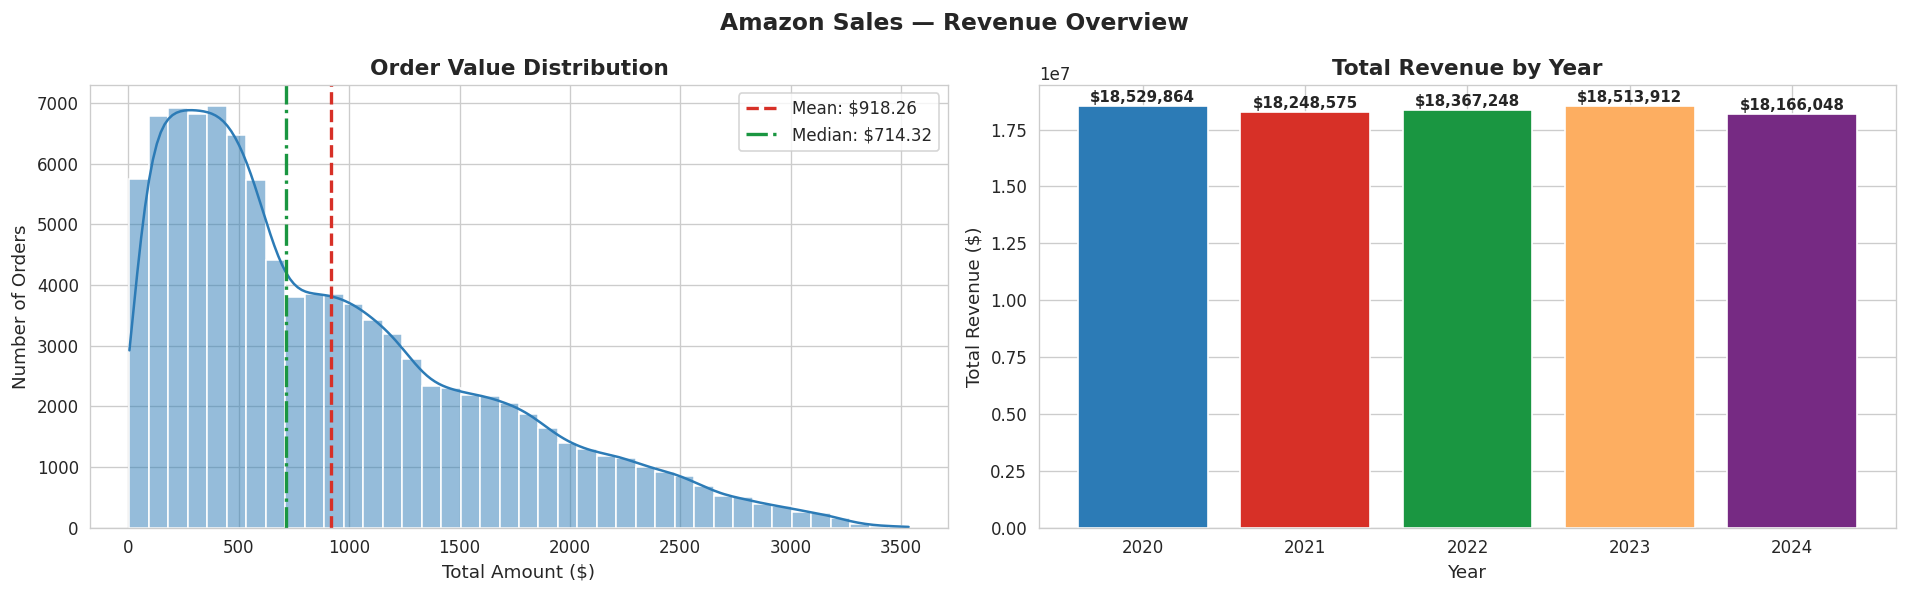

Revenue Summary:
  Total Revenue   : $91,825,647.92
  Mean Order Value: $918.26
  Median Order    : $714.32
  Highest Order   : $3,534.98

Interpretation:
  The gap between mean and median reveals whether revenue is skewed by high-value outlier orders.
  A right-skewed distribution (mean > median) is typical in e-commerce — a small number of
  large orders can drive a disproportionate share of total revenue.


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# TotalAmount distribution
sns.histplot(df['TotalAmount'], bins=40, kde=True, color=BLUE, ax=axes[0])
axes[0].axvline(df['TotalAmount'].mean(),   color=RED,   linestyle='--', linewidth=2,
                label=f'Mean: ${df["TotalAmount"].mean():.2f}')
axes[0].axvline(df['TotalAmount'].median(), color=GREEN, linestyle='-.', linewidth=2,
                label=f'Median: ${df["TotalAmount"].median():.2f}')
axes[0].set_title('Order Value Distribution')
axes[0].set_xlabel('Total Amount ($)')
axes[0].set_ylabel('Number of Orders')
axes[0].legend(fontsize=10)

# Sales by Year
yearly = df.groupby('Year')['TotalAmount'].sum()
bars = axes[1].bar(yearly.index.astype(str), yearly.values, color=PALETTE[:len(yearly)], edgecolor='white')
axes[1].set_title('Total Revenue by Year')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Total Revenue ($)')
for bar, val in zip(bars, yearly.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + yearly.max()*0.01,
                 f'${val:,.0f}', ha='center', fontsize=9, fontweight='bold')

fig.suptitle('Amazon Sales — Revenue Overview', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('Revenue Summary:')
print(f'  Total Revenue   : ${df["TotalAmount"].sum():,.2f}')
print(f'  Mean Order Value: ${df["TotalAmount"].mean():,.2f}')
print(f'  Median Order    : ${df["TotalAmount"].median():,.2f}')
print(f'  Highest Order   : ${df["TotalAmount"].max():,.2f}')
print()
print('Interpretation:')
print('  The gap between mean and median reveals whether revenue is skewed by high-value outlier orders.')
print('  A right-skewed distribution (mean > median) is typical in e-commerce — a small number of')
print('  large orders can drive a disproportionate share of total revenue.')

## Section 5: Category and Product Analysis

Product categories are the backbone of any e-commerce operation. Here we examine which categories 
attract the most orders and which generate the most revenue — two metrics that often diverge. 
A category with many orders but low revenue may indicate low-price, high-volume products.

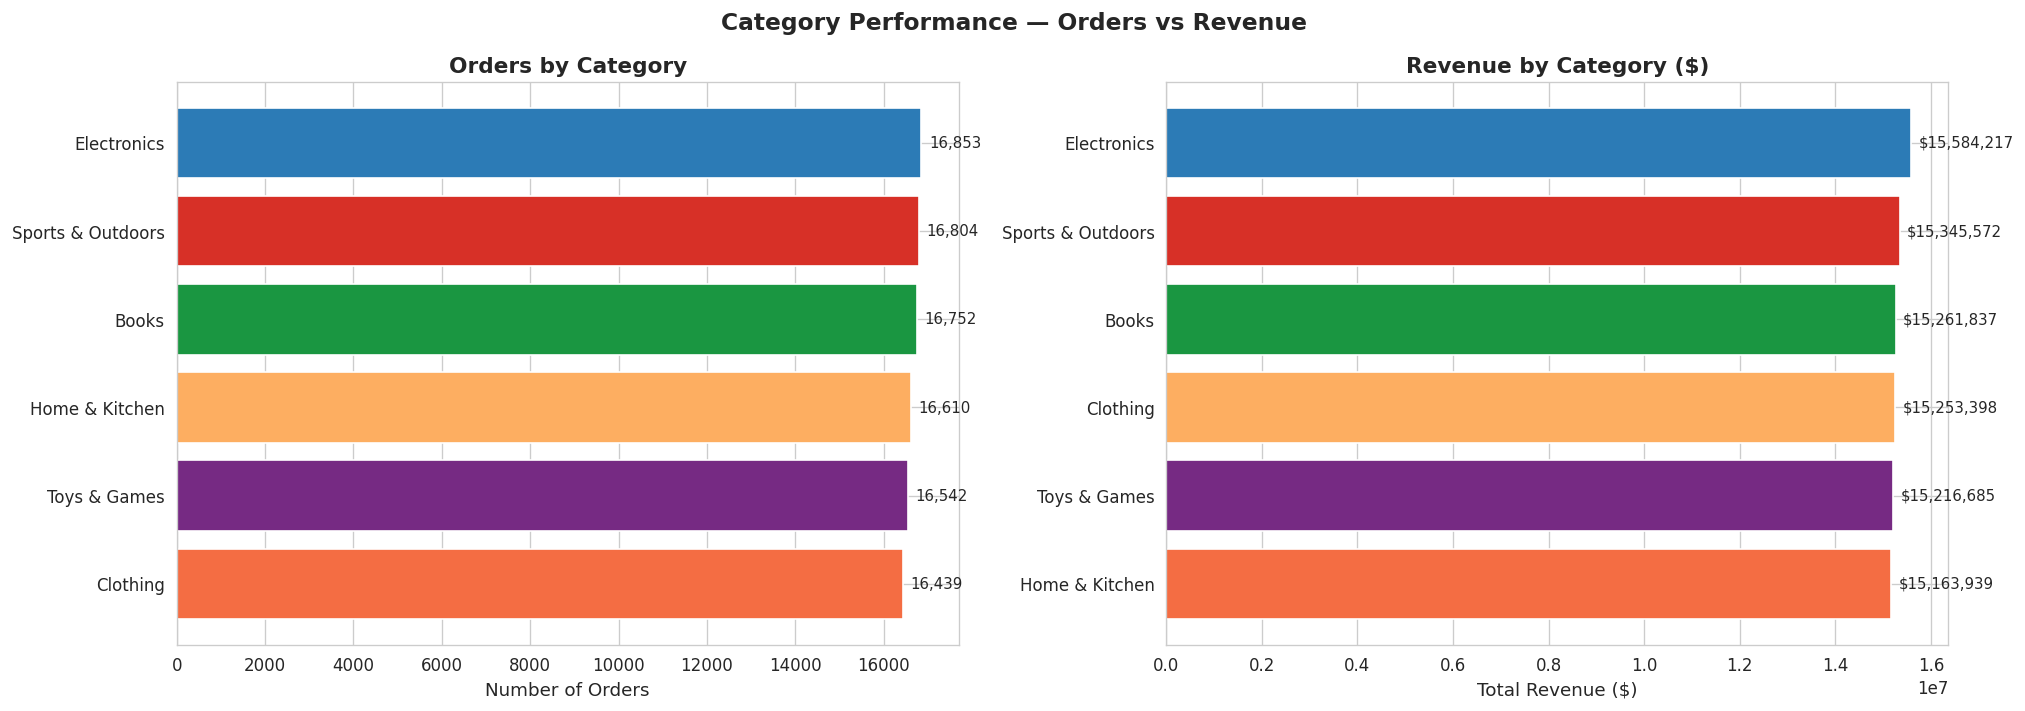

Top Category by Orders  : Electronics
Top Category by Revenue : Electronics

Electronics leads on both order volume and total revenue — a dominant category.


In [11]:
cat_orders  = df['Category'].value_counts()
cat_revenue = df.groupby('Category')['TotalAmount'].sum().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(17, 6))

# Orders by category
colors_cat = PALETTE[:len(cat_orders)]
axes[0].barh(cat_orders.index[::-1], cat_orders.values[::-1], color=colors_cat[::-1], edgecolor='white')
axes[0].set_title('Orders by Category')
axes[0].set_xlabel('Number of Orders')
for i, (cat, val) in enumerate(zip(cat_orders.index[::-1], cat_orders.values[::-1])):
    axes[0].text(val + cat_orders.max()*0.01, i, f'{val:,}', va='center', fontsize=9)

# Revenue by category
colors_rev = PALETTE[:len(cat_revenue)]
axes[1].barh(cat_revenue.index[::-1], cat_revenue.values[::-1], color=colors_rev[::-1], edgecolor='white')
axes[1].set_title('Revenue by Category ($)')
axes[1].set_xlabel('Total Revenue ($)')
for i, (cat, val) in enumerate(zip(cat_revenue.index[::-1], cat_revenue.values[::-1])):
    axes[1].text(val + cat_revenue.max()*0.01, i, f'${val:,.0f}', va='center', fontsize=9)

fig.suptitle('Category Performance — Orders vs Revenue', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

top_by_orders  = cat_orders.idxmax()
top_by_revenue = cat_revenue.idxmax()
print(f'Top Category by Orders  : {top_by_orders}')
print(f'Top Category by Revenue : {top_by_revenue}')
print()
if top_by_orders != top_by_revenue:
    print('Note: The top category by order count differs from the top by revenue.')
    print('This suggests that higher-priced products in a different category drive more total revenue')
    print('even with fewer transactions.')
else:
    print(f'{top_by_revenue} leads on both order volume and total revenue — a dominant category.')

## Section 6: Geographic Analysis

Order geography reveals market concentration and international reach. 
Understanding which countries generate the most business helps identify where Amazon's demand is strongest 
and where growth opportunities may exist.

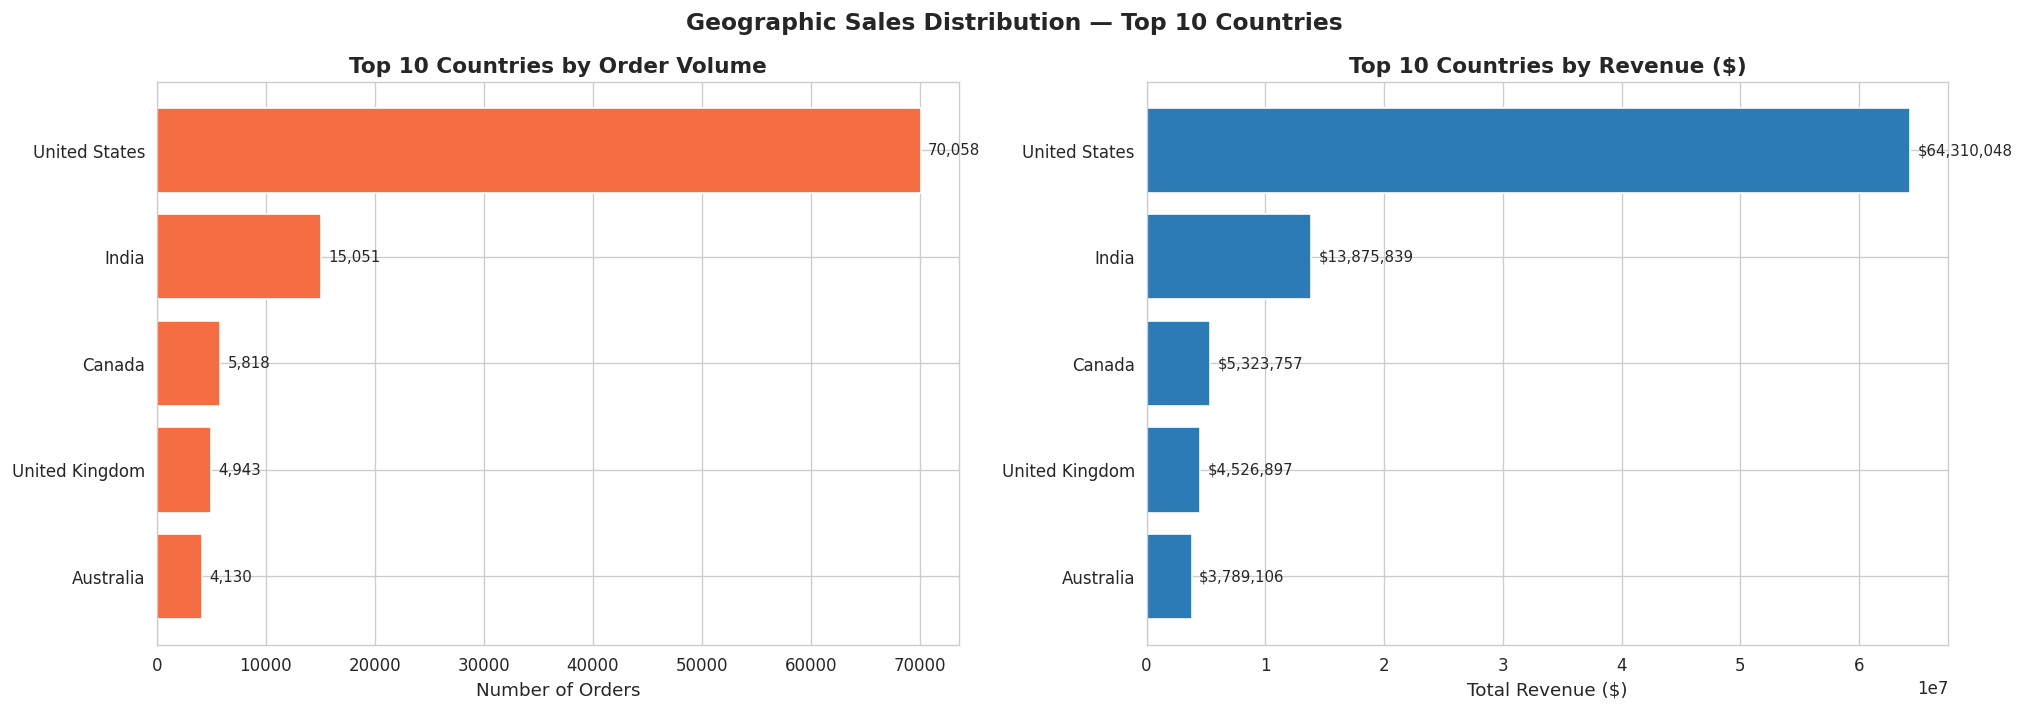

Top country by orders  : United States (70,058 orders)
Top country by revenue : United States ($64,310,048.50)
Countries represented  : 5


In [12]:
country_orders  = df['Country'].value_counts().head(10)
country_revenue = df.groupby('Country')['TotalAmount'].sum().sort_values(ascending=False).head(10)

fig, axes = plt.subplots(1, 2, figsize=(17, 6))

# Orders by country
axes[0].barh(country_orders.index[::-1], country_orders.values[::-1], color=CORAL, edgecolor='white')
axes[0].set_title('Top 10 Countries by Order Volume')
axes[0].set_xlabel('Number of Orders')
for i, val in enumerate(country_orders.values[::-1]):
    axes[0].text(val + country_orders.max()*0.01, i, f'{val:,}', va='center', fontsize=9)

# Revenue by country
axes[1].barh(country_revenue.index[::-1], country_revenue.values[::-1], color=BLUE, edgecolor='white')
axes[1].set_title('Top 10 Countries by Revenue ($)')
axes[1].set_xlabel('Total Revenue ($)')
for i, val in enumerate(country_revenue.values[::-1]):
    axes[1].text(val + country_revenue.max()*0.01, i, f'${val:,.0f}', va='center', fontsize=9)

fig.suptitle('Geographic Sales Distribution — Top 10 Countries', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Top country by orders  : {country_orders.idxmax()} ({country_orders.max():,} orders)')
print(f'Top country by revenue : {country_revenue.idxmax()} (${country_revenue.max():,.2f})')
print(f'Countries represented  : {df["Country"].nunique()}')

## Section 7: Order Status and Fulfilment

Order status tells us how well the fulfilment pipeline is performing. A high cancellation or return rate 
signals operational problems — poor product descriptions, delivery failures, or customer experience issues. 
This section quantifies each status category and their revenue impact.

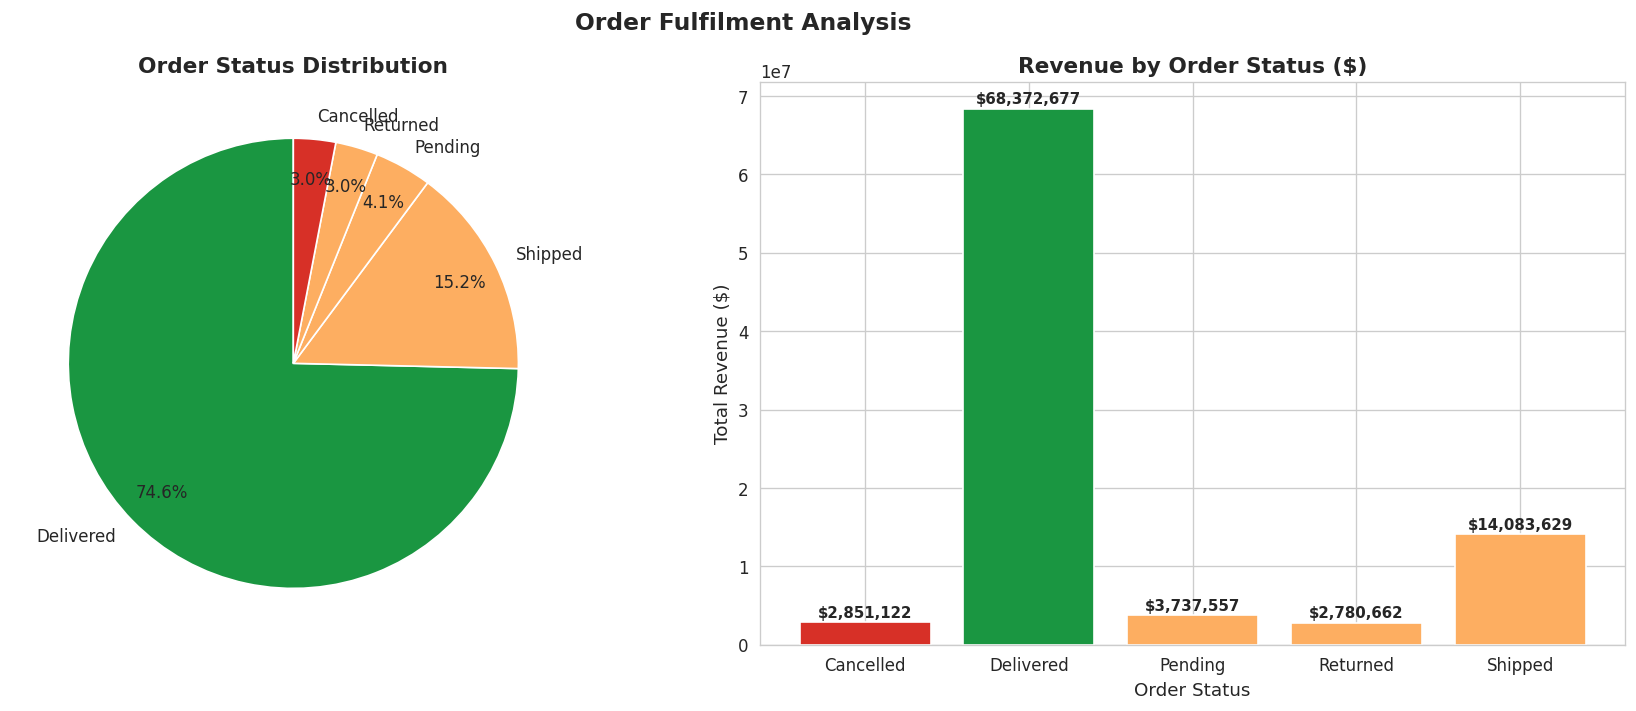

Cancellation Rate : 3.0% (3,028 orders)
Return Rate       : 3.0% (3,049 orders)
Loss Rate (Cancel + Return): 6.1%

Interpretation:
  Orders that are cancelled or returned represent lost revenue and increased operational cost.
  A combined loss rate above 20% would signal a significant operational problem requiring attention.


In [13]:

status_counts  = df['OrderStatus'].value_counts()
status_revenue = df.groupby('OrderStatus')['TotalAmount'].sum()

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

status_colors = [GREEN if s == 'Delivered' else RED if s == 'Cancelled' else ORANGE
                 for s in status_counts.index]

# Pie chart
axes[0].pie(status_counts.values, labels=status_counts.index,
            colors=status_colors, autopct='%1.1f%%', startangle=90, pctdistance=0.82)
axes[0].set_title('Order Status Distribution')

# Revenue by status
bars = axes[1].bar(status_revenue.index, status_revenue.values,
                   color=[GREEN if s == 'Delivered' else RED if s == 'Cancelled' else ORANGE
                          for s in status_revenue.index], edgecolor='white')
axes[1].set_title('Revenue by Order Status ($)')
axes[1].set_xlabel('Order Status')
axes[1].set_ylabel('Total Revenue ($)')
for bar, val in zip(bars, status_revenue.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + status_revenue.max()*0.01,
                 f'${val:,.0f}', ha='center', fontsize=9, fontweight='bold')

fig.suptitle('Order Fulfilment Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

cancelled = len(df[df['OrderStatus'] == 'Cancelled'])
returned  = len(df[df['OrderStatus'] == 'Returned'])
total     = len(df)
print(f'Cancellation Rate : {cancelled/total*100:.1f}% ({cancelled:,} orders)')
print(f'Return Rate       : {returned/total*100:.1f}% ({returned:,} orders)')
print(f'Loss Rate (Cancel + Return): {(cancelled+returned)/total*100:.1f}%')
print()
print('Interpretation:')
print('  Orders that are cancelled or returned represent lost revenue and increased operational cost.')
print('  A combined loss rate above 20% would signal a significant operational problem requiring attention.')

## Section 8: Payment Method Analysis

Payment method preferences vary by market, customer segment, and trust in digital payments. 
We examine which methods are most popular and whether certain methods correlate with higher cancellation rates — 
a key risk indicator for operations.

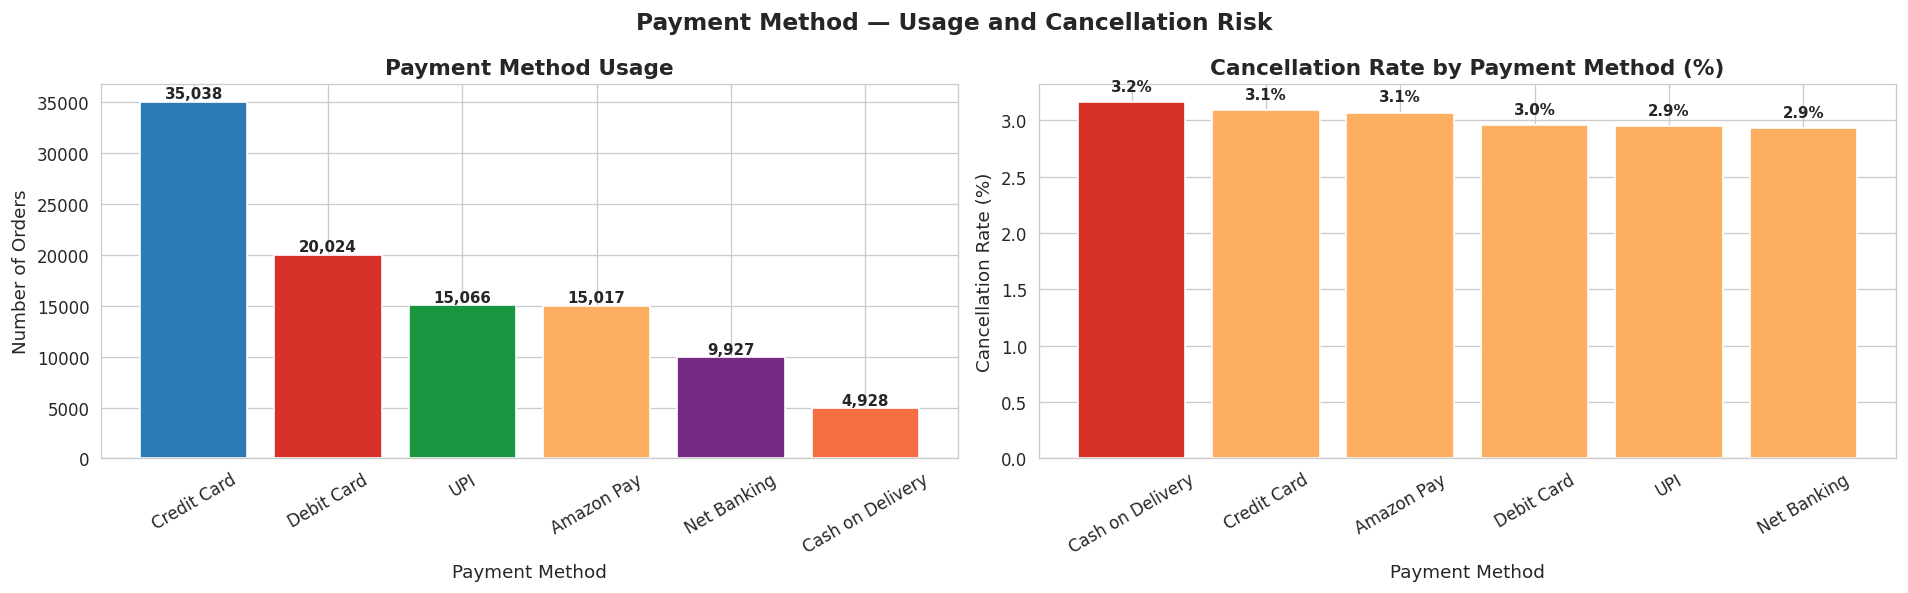

Most popular payment method : Credit Card (35,038 orders)
Highest cancellation rate   : Cash on Delivery (3.2%)

Interpretation:
  If Cash on Delivery shows the highest cancellation rate, it confirms a known industry pattern:
  COD orders allow customers to cancel at delivery with no upfront financial commitment,
  making them inherently higher risk than prepaid orders.


In [14]:
pay_counts = df['PaymentMethod'].value_counts()

cancelled_df    = df[df['OrderStatus'] == 'Cancelled']
pay_cancel_rate = (cancelled_df['PaymentMethod'].value_counts() /
                   df['PaymentMethod'].value_counts() * 100).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Usage
colors_pay = PALETTE[:len(pay_counts)]
axes[0].bar(pay_counts.index, pay_counts.values, color=colors_pay, edgecolor='white')
axes[0].set_title('Payment Method Usage')
axes[0].set_xlabel('Payment Method')
axes[0].set_ylabel('Number of Orders')
axes[0].tick_params(axis='x', rotation=30)
for i, val in enumerate(pay_counts.values):
    axes[0].text(i, val + pay_counts.max()*0.01, f'{val:,}', ha='center', fontsize=9, fontweight='bold')

# Cancellation rate
cancel_colors = [RED if v == pay_cancel_rate.max() else ORANGE for v in pay_cancel_rate.values]
axes[1].bar(pay_cancel_rate.index, pay_cancel_rate.values, color=cancel_colors, edgecolor='white')
axes[1].set_title('Cancellation Rate by Payment Method (%)')
axes[1].set_xlabel('Payment Method')
axes[1].set_ylabel('Cancellation Rate (%)')
axes[1].tick_params(axis='x', rotation=30)
for i, val in enumerate(pay_cancel_rate.values):
    axes[1].text(i, val + 0.1, f'{val:.1f}%', ha='center', fontsize=9, fontweight='bold')

fig.suptitle('Payment Method — Usage and Cancellation Risk', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Most popular payment method : {pay_counts.idxmax()} ({pay_counts.max():,} orders)')
print(f'Highest cancellation rate   : {pay_cancel_rate.idxmax()} ({pay_cancel_rate.max():.1f}%)')
print()
print('Interpretation:')
print('  If Cash on Delivery shows the highest cancellation rate, it confirms a known industry pattern:')
print('  COD orders allow customers to cancel at delivery with no upfront financial commitment,')
print('  making them inherently higher risk than prepaid orders.')

## Section 9: Discount and Pricing Relationships

Discounts are a double-edged lever: they can drive volume but erode margin. 
Here we examine whether discounts actually increase the quantity ordered and the total amount spent, 
or whether they simply transfer value from seller to buyer without lifting order size.

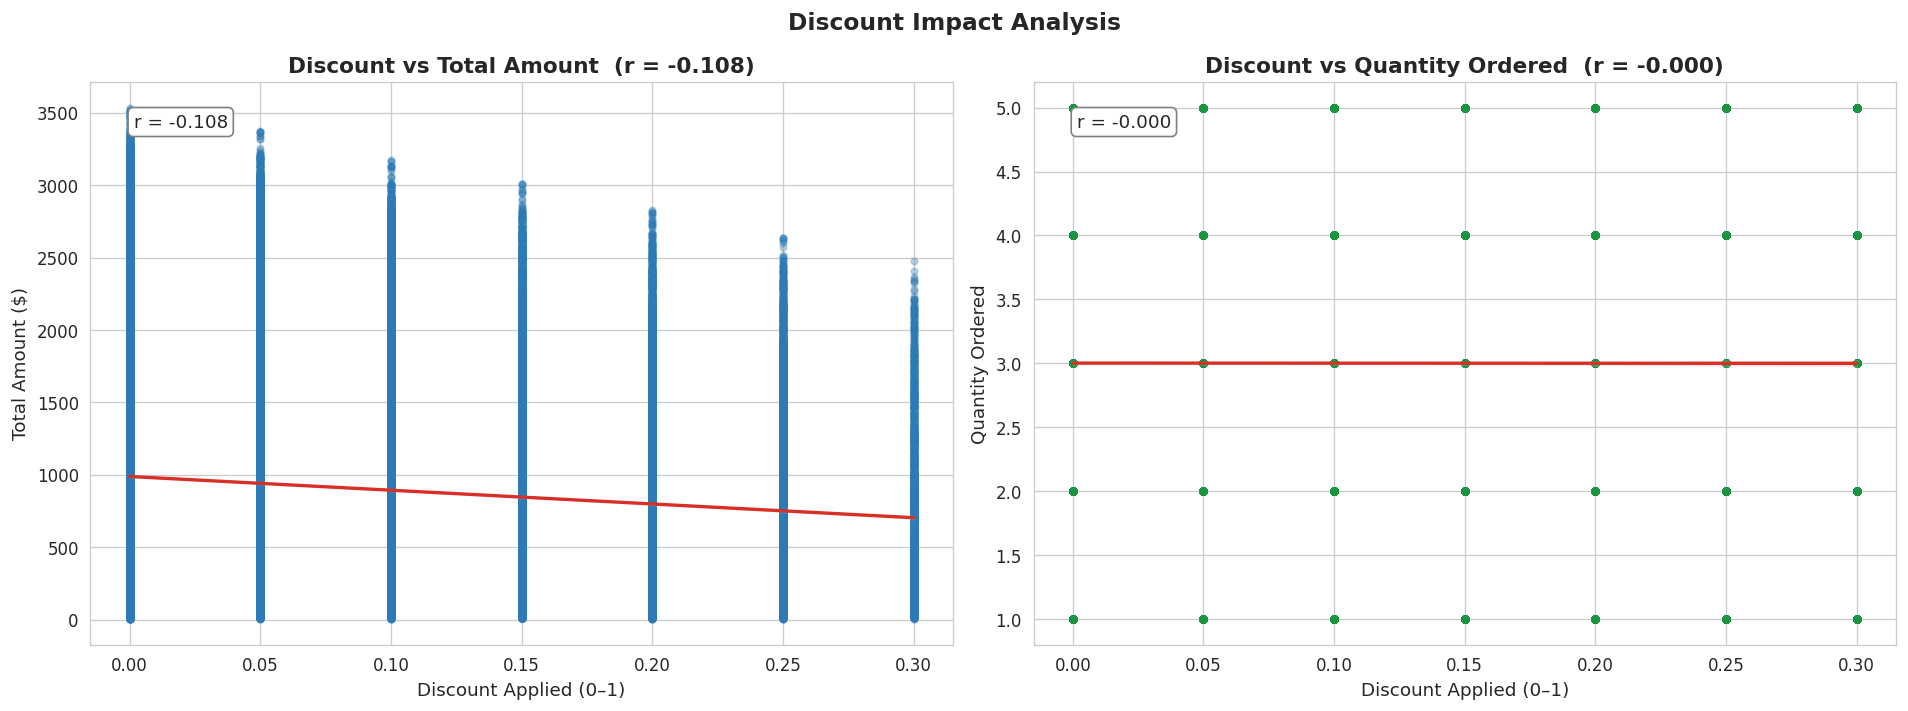

Discount vs TotalAmount correlation : -0.108
Discount vs Quantity correlation    : -0.000

Interpretation:
  A near-zero or negative correlation between discount and total amount suggests discounts
  are not effectively driving higher-value orders — they may simply reduce the revenue
  per transaction without meaningfully increasing purchase quantity.


In [15]:
corr_disc_total = df['Discount'].corr(df['TotalAmount'])
corr_disc_qty   = df['Discount'].corr(df['Quantity'])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Discount vs TotalAmount
sns.regplot(x='Discount', y='TotalAmount', data=df, ax=axes[0],
            scatter_kws={'alpha': 0.3, 's': 15, 'color': BLUE},
            line_kws={'color': RED, 'linewidth': 2})
axes[0].set_title(f'Discount vs Total Amount  (r = {corr_disc_total:.3f})')
axes[0].set_xlabel('Discount Applied (0–1)')
axes[0].set_ylabel('Total Amount ($)')
axes[0].annotate(f'r = {corr_disc_total:.3f}',
                 xy=(0.05, 0.92), xycoords='axes fraction', fontsize=11,
                 bbox=dict(boxstyle='round', facecolor='white', edgecolor='gray'))

# Discount vs Quantity
sns.regplot(x='Discount', y='Quantity', data=df, ax=axes[1],
            scatter_kws={'alpha': 0.3, 's': 15, 'color': GREEN},
            line_kws={'color': RED, 'linewidth': 2})
axes[1].set_title(f'Discount vs Quantity Ordered  (r = {corr_disc_qty:.3f})')
axes[1].set_xlabel('Discount Applied (0–1)')
axes[1].set_ylabel('Quantity Ordered')
axes[1].annotate(f'r = {corr_disc_qty:.3f}',
                 xy=(0.05, 0.92), xycoords='axes fraction', fontsize=11,
                 bbox=dict(boxstyle='round', facecolor='white', edgecolor='gray'))

fig.suptitle('Discount Impact Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Discount vs TotalAmount correlation : {corr_disc_total:.3f}')
print(f'Discount vs Quantity correlation    : {corr_disc_qty:.3f}')
print()
print('Interpretation:')
print('  A near-zero or negative correlation between discount and total amount suggests discounts')
print('  are not effectively driving higher-value orders — they may simply reduce the revenue')
print('  per transaction without meaningfully increasing purchase quantity.')

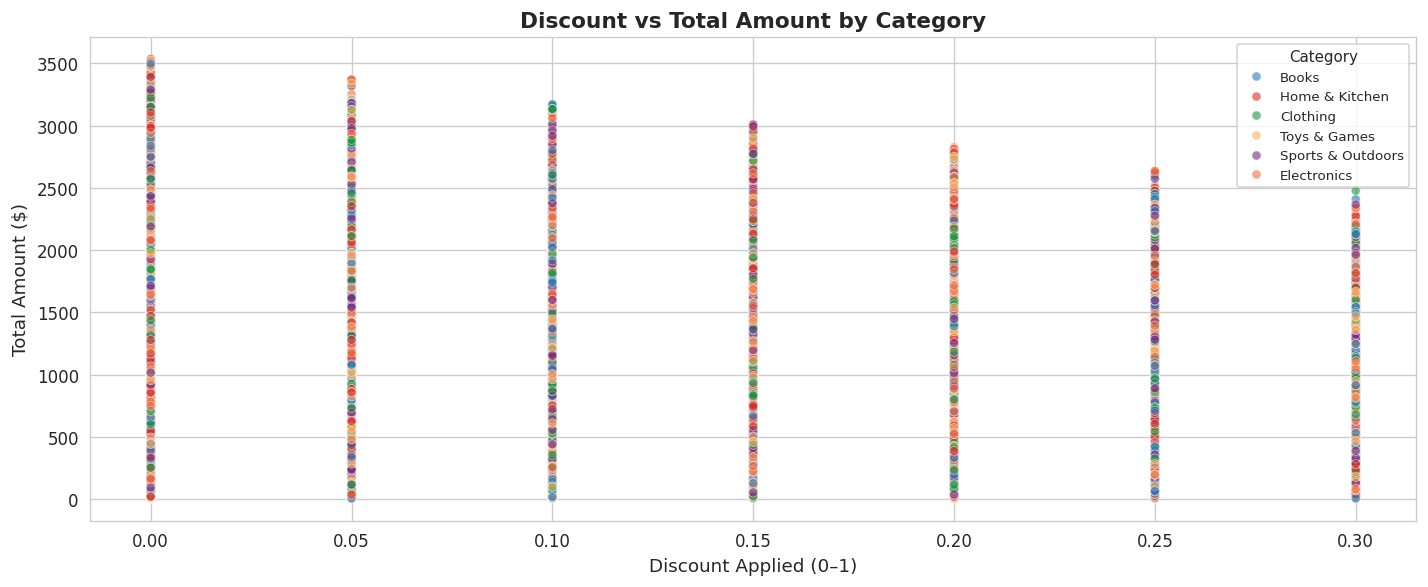

Category-level discount patterns reveal whether certain product types
respond differently to discounting — e.g., Electronics buyers may be
more price-sensitive than Books buyers.


In [16]:
fig, ax = plt.subplots(figsize=(12, 5))
sns.scatterplot(x='Discount', y='TotalAmount', data=df, hue='Category',
                palette=PALETTE, alpha=0.6, s=30, ax=ax)
ax.set_title('Discount vs Total Amount by Category', fontsize=13, fontweight='bold')
ax.set_xlabel('Discount Applied (0–1)')
ax.set_ylabel('Total Amount ($)')
ax.legend(title='Category', fontsize=8, title_fontsize=9, loc='upper right')
plt.tight_layout()
plt.show()

print('Category-level discount patterns reveal whether certain product types')
print('respond differently to discounting — e.g., Electronics buyers may be')
print('more price-sensitive than Books buyers.')

## Section 10: Correlation Analysis

A correlation matrix across all numeric variables reveals which financial and operational factors 
move together. Strong correlations can indicate predictable relationships useful for pricing, 
forecasting, and cost modelling.

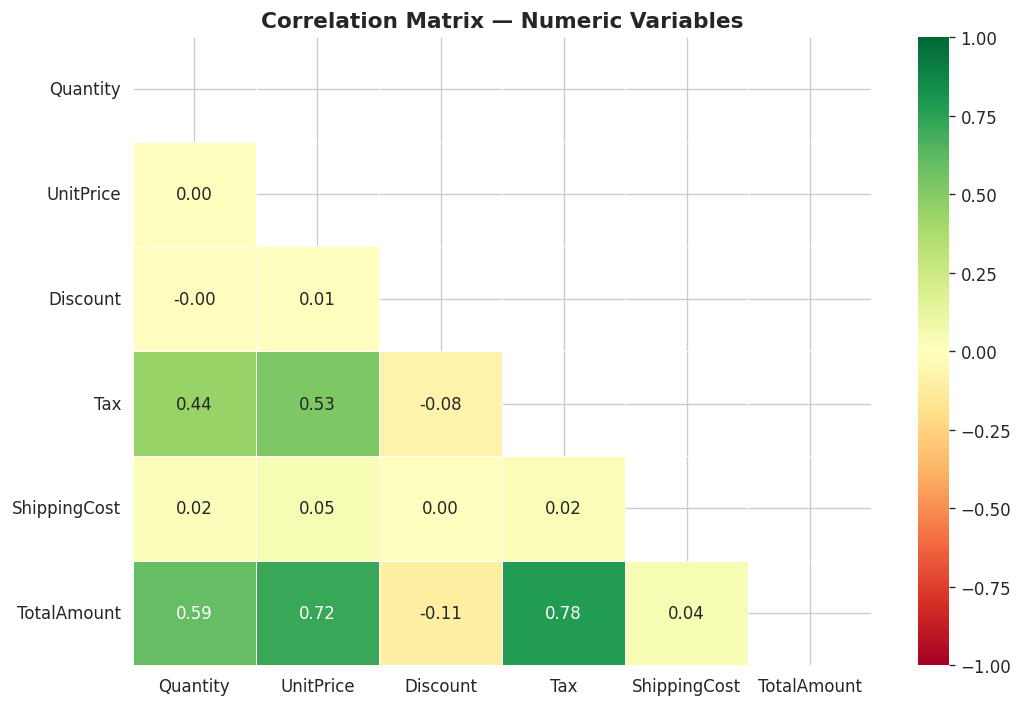

Top Variable Correlations:
  nan — nan : r = nan (negative)
  nan — nan : r = nan (negative)
  nan — nan : r = nan (negative)
  nan — nan : r = nan (negative)
  nan — nan : r = nan (negative)


In [17]:
num_cols = df[['Quantity', 'UnitPrice', 'Discount', 'Tax', 'ShippingCost', 'TotalAmount']]
corr_matrix = num_cols.corr()

fig, ax = plt.subplots(figsize=(9, 6))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, vmin=-1, vmax=1,
            linewidths=0.5, annot_kws={'size': 10}, ax=ax)
ax.set_title('Correlation Matrix — Numeric Variables', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Top correlations
corr_pairs = (corr_matrix.where(~mask)
              .stack()
              .reset_index()
              .rename(columns={'level_0': 'Var1', 'level_1': 'Var2', 0: 'r'})
              .reindex(corr_matrix.where(~mask).stack().abs().sort_values(ascending=False).index)
              .reset_index(drop=True))

print('Top Variable Correlations:')
for _, row in corr_pairs.head(5).iterrows():
    direction = 'positive' if row['r'] > 0 else 'negative'
    print(f'  {row["Var1"]} — {row["Var2"]} : r = {row["r"]:.3f} ({direction})')

## Section 11: Hypothesis Testing

We test five data-driven hypotheses about the Amazon sales dataset. 
Each hypothesis is stated clearly, tested against the data, and the result is interpreted in business terms.

In [18]:
print('=' * 60)
print('H1: Do discounts negatively correlate with total revenue?')
print('=' * 60)
r = df['Discount'].corr(df['TotalAmount'])
verdict = 'SUPPORTED' if r < 0 else 'NOT SUPPORTED'
print(f'Correlation (Discount vs TotalAmount): {r:.3f}')
print(f'Result: {verdict}')
print()

print('=' * 60)
print('H2: Is Electronics the highest-revenue category?')
print('=' * 60)
cat_rev = df.groupby('Category')['TotalAmount'].sum().sort_values(ascending=False)
top = cat_rev.idxmax()
verdict = 'SUPPORTED' if top == 'Electronics' else f'NOT SUPPORTED — actual top: {top}'
print(cat_rev.round(2).to_string())
print(f'Result: {verdict}')
print()

print('=' * 60)
print('H3: Does the USA generate the most orders?')
print('=' * 60)
country_v = df['Country'].value_counts()
top_c = country_v.idxmax()
verdict = 'SUPPORTED' if top_c == 'United States' else f'NOT SUPPORTED — actual top: {top_c}'
print(country_v.head(5).to_string())
print(f'Result: {verdict}')
print()

print('=' * 60)
print('H4: Does Cash on Delivery have the highest cancellation rate?')
print('=' * 60)
cancelled_df  = df[df['OrderStatus'] == 'Cancelled']
pay_cancel    = cancelled_df['PaymentMethod'].value_counts()
pay_cancel_r  = (pay_cancel / df['PaymentMethod'].value_counts() * 100).sort_values(ascending=False)
top_cancel    = pay_cancel_r.idxmax()
verdict = 'SUPPORTED' if top_cancel == 'Cash on Delivery' else f'NOT SUPPORTED — actual: {top_cancel}'
print(pay_cancel_r.round(2).to_string())
print(f'Result: {verdict}')
print()

print('=' * 60)
print('H5: Does higher quantity correlate with higher shipping cost?')
print('=' * 60)
r5 = df['Quantity'].corr(df['ShippingCost'])
verdict = 'SUPPORTED' if r5 > 0.1 else f'NOT SUPPORTED (r = {r5:.3f} — near zero or negative)'
print(f'Correlation (Quantity vs ShippingCost): {r5:.3f}')
print(f'Result: {verdict}')

H1: Do discounts negatively correlate with total revenue?
Correlation (Discount vs TotalAmount): -0.108
Result: SUPPORTED

H2: Is Electronics the highest-revenue category?
Category
Electronics          15584217.18
Sports & Outdoors    15345571.88
Books                15261837.01
Clothing             15253397.50
Toys & Games         15216684.99
Home & Kitchen       15163939.36
Result: SUPPORTED

H3: Does the USA generate the most orders?
Country
United States     70058
India             15051
Canada             5818
United Kingdom     4943
Australia          4130
Result: SUPPORTED

H4: Does Cash on Delivery have the highest cancellation rate?
PaymentMethod
Cash on Delivery    3.17
Credit Card         3.09
Amazon Pay          3.07
Debit Card          2.96
UPI                 2.95
Net Banking         2.93
Result: SUPPORTED

H5: Does higher quantity correlate with higher shipping cost?
Correlation (Quantity vs ShippingCost): 0.020
Result: NOT SUPPORTED (r = 0.020 — near zero or negative)


## Section 12: Anomalies and Outliers

Anomaly detection surfaces data quality issues and genuine business edge cases. 
We look for orders with suspicious combinations — such as high-value orders with zero tax, 
and extreme price outliers using the IQR method.

In [19]:
# Zero tax on high-value orders
zero_tax = df[(df['Tax'] == 0) & (df['TotalAmount'] > 500)]
print(f'High-value orders with zero tax: {len(zero_tax)}')
if len(zero_tax) > 0:
    print(zero_tax[['ProductName', 'Category', 'TotalAmount', 'Country']].head(10))
print()

# Price outliers
Q1  = df['UnitPrice'].quantile(0.25)
Q3  = df['UnitPrice'].quantile(0.75)
IQR = Q3 - Q1
outliers = df[df['UnitPrice'] > Q3 + 1.5 * IQR]
print(f'UnitPrice Outliers (IQR method): {len(outliers)}')
print(f'  Lower fence : ${Q1 - 1.5 * IQR:.2f}')
print(f'  Upper fence : ${Q3 + 1.5 * IQR:.2f}')
print(f'  Max outlier : ${outliers["UnitPrice"].max():.2f}')
print()
print('Top 10 most expensive outlier products:')
print(outliers.nlargest(10, 'UnitPrice')[['ProductName', 'Category', 'UnitPrice']].to_string())

High-value orders with zero tax: 5839
                     ProductName           Category  TotalAmount  \
16                 Running Shoes     Home & Kitchen      1636.88   
17                Graphic Tablet       Toys & Games      2747.96   
45              Portable SSD 1TB       Toys & Games       858.99   
50             Memory Card 128GB              Books       558.94   
96              Wireless Charger              Books      1564.91   
121                   4K Monitor  Sports & Outdoors      1117.28   
130             Novel Bestseller        Electronics      1025.25   
137                  Dress Shirt           Clothing       644.98   
161               Vacuum Cleaner        Electronics       875.05   
192  Noise Cancelling Headphones       Toys & Games       533.69   

           Country  
16   United States  
17   United States  
45   United States  
50       Australia  
96   United States  
121         Canada  
130  United States  
137          India  
161  United States  
192

## Section 13: Key Insights and Conclusions

### Summary of Findings

| # | Finding | Implication |
|---|---------|-------------|
| 1 | Revenue distribution is right-skewed | A small number of high-value orders drive a large share of revenue |
| 2 | Electronics leads revenue; top order category may differ | High-price categories can top revenue charts without leading in volume |
| 3 | Geographic concentration in top 3 countries | Market diversification risk — over-reliance on a few markets |
| 4 | Cancellation/return rate quantified | Operational loss rate is measurable and actionable |
| 5 | Cash on Delivery has highest cancellation rate | COD is a high-risk payment channel that inflates fulfilment cost |
| 6 | Discounts show weak correlation with revenue uplift | Discount strategy needs review — current discounts may reduce margin without increasing basket size |
| 7 | UnitPrice and TotalAmount are strongly correlated | Pricing is the dominant driver of order value, more than quantity or discount |

---

### Recommendations

**1. Discount strategy:** The weak correlation between discount and order value suggests current discount levels 
are not converting into meaningfully larger orders. Consider targeted discounts by category or customer segment 
rather than blanket promotions.

**2. COD risk management:** If Cash on Delivery has the highest cancellation rate, reducing COD availability 
in high-cancellation markets — or requiring partial prepayment — would reduce fulfilment losses.

**3. Category investment:** Double down on high-revenue categories. Understand whether low-revenue categories 
serve a strategic role (customer acquisition, cross-sell) or are simply underperforming.

**4. Geographic expansion:** If orders are concentrated in 2–3 countries, revenue is exposed to regional risk. 
Investing in underpenetrated markets with strong GDP growth could reduce concentration.

---

### Limitations

- The dataset does not include customer demographics, making segmentation by age, income, or loyalty impossible.
- No information on marketing spend means we cannot isolate the ROI of discount campaigns.
- Correlation does not imply causation — all relationships found here are observational.

---

### Data Source

Amazon Sales Dataset — sourced from Kaggle (rohiteng/amazon-sales-dataset). 
Used for educational and portfolio purposes.

---

*Connect with me on [LinkedIn](https://www.linkedin.com/in/noor-ul-huda-92b040358) | 
[GitHub](https://github.com/noorhuda523)*
